# Quantifying the drivers of displacement durations using double machine learning

This notebook is companion code to a submitted manuscript on protracted displacement after disasters. 

In [1]:
# Dependencies and imports
import os
import pandas as pd
import matplotlib.pyplot as plt

from util.plotters import plot_config
from util.dml import repeat_dml, plot_results, extract_evaluation_table, plot_eval_metrics

plot_config()

%matplotlib inline
%config InlineBackend.figure_format = 'svg'

Using default theme



## Identification

[DAGgity.net](https://www.dagitty.net/) was used to draw causal diagrams and identify adjustment sets. Domain knowledge from literature review on household displacement and return in disasters was used to design the survey (and thus to measure relevant variables), as well as the likely associations between the relevant variables. Adjustment sets were identified to estimate direct effects. The DAG can be replicated with the following code:


    dag {
    bb="0,0,1,1"
    DisplacementDuration [outcome,pos="0.818,0.401"]
    HazardExposure [pos="0.545,0.613"]
    HouseholdAspirationStay [pos="0.326,0.586"]
    HouseholdChildren [pos="0.074,0.217"]
    HouseholdDwellingType [pos="0.448,0.453"]
    HouseholdEducation [pos="0.336,0.178"]
    HouseholdElderly [pos="0.077,0.138"]
    HouseholdHouseQuality [pos="0.448,0.325"]
    HouseholdIncome [adjusted,pos="0.333,0.264"]
    HouseholdLivelihood [adjusted,pos="0.183,0.316"]
    HouseholdPlaceAttachment [adjusted,pos="0.227,0.420"]
    HouseholdSize [pos="0.183,0.180"]
    HouseholdTenure [exposure,pos="0.174,0.544"]
    ImpactCasualty [adjusted,pos="0.673,0.272"]
    ImpactCommunityDamage [adjusted,pos="0.686,0.515"]
    ImpactHomeDamage [adjusted,pos="0.580,0.389"]
    HazardExposure -> HouseholdDwellingType 
    HazardExposure -> ImpactCommunityDamage
    HouseholdAspirationStay -> DisplacementDuration
    HouseholdChildren -> HouseholdSize
    HouseholdDwellingType -> HouseholdHouseQuality
    HouseholdDwellingType -> ImpactHomeDamage
    HouseholdEducation -> HouseholdIncome
    HouseholdElderly -> HouseholdSize
    HouseholdHouseQuality -> ImpactHomeDamage
    HouseholdIncome -> DisplacementDuration
    HouseholdIncome -> HouseholdDwellingType
    HouseholdIncome -> HouseholdHouseQuality
    HouseholdLivelihood -> DisplacementDuration
    HouseholdLivelihood -> HouseholdDwellingType
    HouseholdLivelihood -> HouseholdIncome
    HouseholdLivelihood -> HouseholdPlaceAttachment
    HouseholdPlaceAttachment -> DisplacementDuration
    HouseholdPlaceAttachment -> HouseholdAspirationStay
    HouseholdSize -> DisplacementDuration
    HouseholdSize -> HouseholdIncome
    HouseholdTenure -> DisplacementDuration
    HouseholdTenure -> HouseholdHouseQuality
    HouseholdTenure -> HouseholdPlaceAttachment
    ImpactCasualty -> DisplacementDuration
    ImpactCommunityDamage -> DisplacementDuration
    ImpactCommunityDamage -> ImpactCasualty
    ImpactHomeDamage -> DisplacementDuration
    ImpactHomeDamage -> ImpactCasualty
    ImpactHomeDamage -> ImpactCommunityDamage
    }

Justifications:

* **HouseholdChildren -> HouseholdSize:** Larger households have more members, and are thus more likely to have children. Therefore, the presence of children can be an indication of a larger household size.

* **HouseholdElderly -> HouseholdSize:** Larger households have more members, and are thus more likely to have elderly. Therefore, the presence of elderly can be an indication of a larger household size.

* **HouseholdDwellingType -> HouseholdHouseQuality:** Different types of dwellings are more or less likely be perceived as a different quality level, built during a different time period, and to degrade over time at different rates.

* **HouseholdDwellingType -> ImpactHomeDamage:** Different dwelling types are more or less vulnerable to the impacts of disasters, including damage induced by earthquake ground shaking, liquefaction, and tsunami.

* **HouseholdEducation -> HouseholdIncome:** Higher levels of educational attainment are often linked to higher earnings

* **HouseholdSize -> HouseholdIncome:** Larger household sizes are likely to have more sources of income, thus increasing the total household income.

* **HouseholdIncome -> HouseholdDwellingType:** A household's income level influences the type of dwelling they can afford to buy or build.

* **HouseholdIncome -> HouseholdHouseQuality:** A household's income level influences the quality of housing they can afford to buy or build, repair, and/or upgrade.

* **HouseholdLivelihood -> HouseholdDwellingType:** Households with different livelihoods tend to occupy different areas, which influences the type of construction. For example, households near the coast may be more likely to be stilted.

* **HouseholdLivelihood -> HouseholdIncome:** Different occupation or livelihood types are likely to bring in different levels of income.

* **HouseholdLivelihood -> HouseholdPlaceAttachment:** Certain livelihood types may increase place dependence, such as agricultural (e.g., fishing, farming) liveihoods.

* **HouseholdPlaceAttachment -> HouseholdAspirationStay:** A person's sense of emotional connectedness to the place they live will influence their desire to stay or relocate, independent of disasters.

* **HouseholdHouseQuality -> ImpactHomeDamage:** The quality of home is an indication of its physical vulnerability to disasters.

* **HouseholdTenure -> HouseholdHouseQuality:** Households that own their home may be more incentivized to upkeep or upgrade their home.

* **HouseholdTenure -> HouseholdPlaceAttachment:** Home ownership has been shown to be significantly associated with higher place identity (Anton and Lawrence 2014)

* **HazardExposure -> HouseholdDwellingType:** Different environments (e.g., along the coast, near a forest) are likely to use different construction materials and build different dwelling types.

* **HazardExposure -> ImpactCommunityDamage:** The presence of secondary perils (e.g., liquefaction, tsunami) can significantly affect the extent and degree of damage in a given neighborhood.

* **ImpactHomeDamage -> ImpactCasualty:** Especially in earthquakes, casualties are often driven by the collapse of homes.

* **ImpactCommunityDamage -> ImpactCasualty:** The extent of damage in the commuity, which is also influenced by the presence of secondary perils, can also incur casualties (e.g., buried by liquefaction/landslide, drowned in tsunami)

* **ImpactHomeDamage -> ImpactCommunityDamage:** The extent of damage in a community is partially contributed to by the extent of damage of individual homes in that community.

* **ImpactHomeDamage -> DisplacementDuration:** There is substantial evidence that housing damage is a primary driver of disaster displacement and displacement durations (Paul et al. 2024)

* **ImpactCommunityDamage -> DisplacementDuration:** Communities that are more heavily damaged have greater reconstruction needs and may take longer to repair, leaving households displaced for longer periods.

* **ImpactCasualty -> DisplacementDuration:** After the 2004 Indian Ocean earthquake and tsunami, households who lost a household member were more likely to move out of their original desa (Gray et al. 2009)

* **HouseholdIncome -> DisplacementDuration:** A household's income influences their level of autonomy over relocation decisions (e.g., whether they can afford moving costs)

* **HouseholdPlaceAttachment -> DisplacementDuration:** Housheolds with stronger place attachment may be more encouraged to return, which will influence their displacement durations

* **HouseholdLivelihood -> DisplacementDuration:** Place-dependent livelihoods may encourage households to return, which will influence their displacement durations

* **HouseholdSize -> DisplacementDuration:** Family and relationships have been a consistent determinant of household return decisions after disasters (Paul et al. 2024), and there is evidence that in baseline conditions that partnered households have `linked lives'  that require a larger number of motivators to prompt relocation (Coulter and Scott 2015).

* **HouseholdTenure -> DisplacementDuration:** Non-homeowners tend to experience more damage in earthquakes and recover less quickly after disasters (Lee and Van Zandt 2019)

* **HouseholdAspirationStay -> DisplacementDuration:** A disaster can cause household's to act on pre-existing plans, including the desire to move (Dickinson 2013)

## References

Anton, Charis E., and Carmen Lawrence. "Home is where the heart is: The effect of place of residence on place attachment and community participation." *Journal of environmental psychology* 40 (2014): 451-461.

Coulter, Rory, and Jacqueline Scott. 2015. “What Motivates Residential Mobility? Re-Examining Self-Reported Reasons for Desiring and Making Residential Moves.” *Population, Space and Place* 21 (4): 354–71. https://doi.org/10.1002/psp.1863.

Dickinson, Simon. Post-disaster Mobilities: Exploring Household Relocation after the Canterbury Earthquakes, MSc thesis, University of Canterbury, 2013. http://dx.doi.org/10.26021/8124

Gray, Clark, Elizabeth Frankenberg, Thomas Gillespie, Cecep Sumantri, and Duncan Thomas. “Population Displacement and Mobility in Sumatra after the Tsunami,” In: *Proceedings of the XXVI International Population Conference of the IUSSP*. 2009.

Lee, Jee Young, and Shannon Van Zandt. "Housing tenure and social vulnerability to disasters: A review of the evidence." *Journal of planning literature* 34, no. 2 (2019): 156-170. https://doi.org/10.1177/0885412218812080

Paul, Nicole, Carmine Galasso, and Jack Baker. 2024. “Household Displacement and Return in Disasters: A Review.” *Natural Hazards Review* 25 (1): 03123006. https://doi.org/10.1061/NHREFO.NHENG-1930.

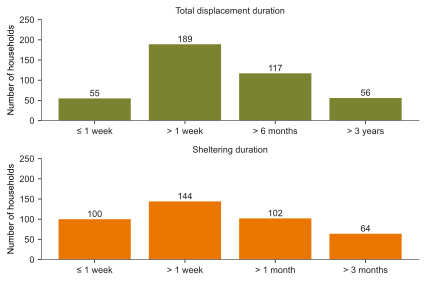

In [2]:
# Organize outcome, treatment, and covariate variables
DAYS_IN_MONTH = 30.437

# Read parsed and anonymized data
df = pd.read_pickle('sample.pkl')
df.head(5)

# Total displacement durations
otype = "total"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 6 months': DAYS_IN_MONTH * 6,
    '> 3 years': DAYS_IN_MONTH * 36,
}
OUTCOME_LEVELS_T = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_T[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1

# Emergency displacement durations
otype = "emergency"
OUTCOME_BINS = {
    '≤ 1 week': 7,
    '> 1 week': 7,
    '> 1 month': DAYS_IN_MONTH,
    '> 3 months': DAYS_IN_MONTH * 3,
}
OUTCOME_LEVELS_E = [otype + '-' + k for k in list(OUTCOME_BINS.keys())]
for outcome in OUTCOME_BINS:
    outcome_label = otype + '-' + outcome
    df[outcome_label] = 0
    threshold = OUTCOME_BINS[outcome]
    is_first_bin = outcome_label == OUTCOME_LEVELS_E[0]
    mask = df[f'duration_{otype}'] * DAYS_IN_MONTH <= threshold if is_first_bin else df[f'duration_{otype}'] * DAYS_IN_MONTH > threshold
    df.loc[mask, outcome_label] = 1



COVARIATES = [
    'home_damage', 'comm_damage',
    'bin_land_tenure', 'bin_dwell_tenure',
    'structure-concrete_heavy', 'structure-wood_light', 'structure-wood_heavy', 'housing_quality',
    'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction',#
    'bin_income', 'edu_household', 
    'bin_household_size', 'elderly', 'children',
    'occupation-agricultural', 'occupation-business', 'occupation-employment', 
    'place_identified', 'place_dependent', 'hometown',
    'tenure_duration', 'aspiration_stay',
]

TREATMENTS = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
    'hazard_type-earthquake_only', 'hazard_type-tsunami', 'hazard_type-liquefaction'] # NOTE: These are all related to disaster impact and so need to consider role of time in identification

# Add new treatments (hot-encoded)
base_vars = ['home_damage', 'comm_damage', 'tenure_duration', 'bin_income', 'bin_household_size', 'edu_household', "bin_land_tenure", "bin_dwell_tenure"]
for base_var in base_vars:
    var_opt = list(df[base_var].cat.categories)
    treatments = [base_var + '-' + opt for opt in var_opt]
    for i in range(len(var_opt)):
        idx = df[base_var] == var_opt[i]
        df[treatments[i]] = 0
        df.loc[idx, treatments[i]] = 1
        TREATMENTS.append(treatments[i])

all_cols = list(set(OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + TREATMENTS + COVARIATES))
data = df.copy()
for col in data.columns:
    if data[col].dtype == 'category':
        if (len(data[col].cat.categories) == 2) and (data[col].cat.categories == ['Yes', 'No']).all():
            data[col] = data[col].apply(lambda x: 1 if x == 'Yes' else 0).astype(float)
        else:
            data[col] = data[col].cat.codes
    elif data[col].dtype == 'bool':
        data[col] = data[col].astype(int)

# Collect frequencies of total and emergency duration bins
freq_total = [df[col].sum() for col in OUTCOME_LEVELS_T]
freq_emergency = [df[col].sum() for col in OUTCOME_LEVELS_E]

# Define labels
labels_total = [k.replace('total-', '') for k in OUTCOME_LEVELS_T]
labels_emergency = [k.replace('emergency-', '') for k in OUTCOME_LEVELS_E]

# Define colors
total_colors = ["#d8d6cc", "#c1c78a", "#7b8230", "#3f4625"]
shelter_colors = ["#e7d3ba", "#f5ab5e", "#ea7600", "#733c1c"]

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(6, 4), sharex=False, sharey=True)

# Total duration subplot (green)
axs[0].bar(labels_total, freq_total, color=total_colors[-2])
axs[0].set_title('Total displacement duration')
axs[0].set_ylabel('Number of households')
for i, count in enumerate(freq_total):
    axs[0].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')

# Emergency duration subplot (orange)
axs[1].bar(labels_emergency, freq_emergency, color=shelter_colors[-2])
axs[1].set_title('Sheltering duration')
axs[1].set_ylabel('Number of households')
axs[1].set_xlabel(None)
for i, count in enumerate(freq_emergency):
    axs[1].text(i, count + 1, f'{int(count)}', ha='center', va='bottom')
axs[1].set_ylim((0, 250))

# For outputs
img_folder = "img"
output_total = {}
output_shelter = {}

# Improve layout
plt.tight_layout()
plt.show()

## Estimation

### Home damage

<img src="dag/home_damage.png" width="600"> <img src="dag/legend.png" width="200">

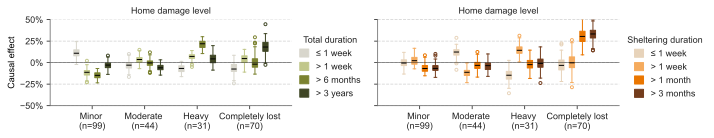

In [3]:
base_var = 'home_damage'
display_name = 'Home damage level'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]

# Direct effect
X = ['comm_damage', 'any_fatality', 'any_injury',
'hazard_type-tsunami', 'hazard_type-liquefaction', 'hazard_type-earthquake_only',
'structure-concrete_heavy', 'structure-wood_light', 'structure-wood_heavy', 'housing_quality',
'bin_income', 'bin_land_tenure', 'bin_dwell_tenure',
]


cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Community damage

<img src="dag/comm_damage.png" width="600"> <img src="dag/legend.png" width="200">

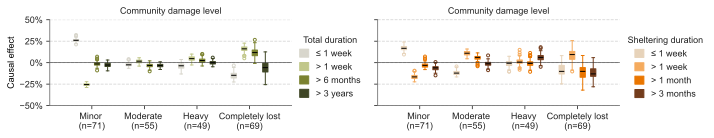

In [4]:
base_var = 'comm_damage'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]
display_name = 'Community damage level'

# Direct effect
X = ['home_damage', 'any_fatality', 'any_injury',
'hazard_type-tsunami', 'hazard_type-liquefaction', 'hazard_type-earthquake_only'
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Casualty

<img src="dag/casualty.png" width="600"> <img src="dag/legend.png" width="200">

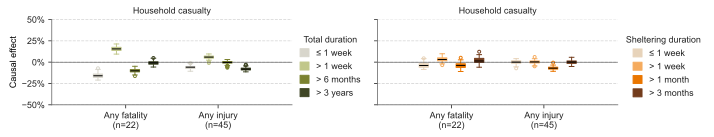

In [5]:
TREATMENTS = ['any_fatality', 'any_injury']
display_name = 'Household casualty'

# Direct effect
X = ['home_damage', 'comm_damage']

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X


results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_casualty.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Hazard exposure

<img src="dag/hazard_exposure.png" width="600"> <img src="dag/legend.png" width="200">

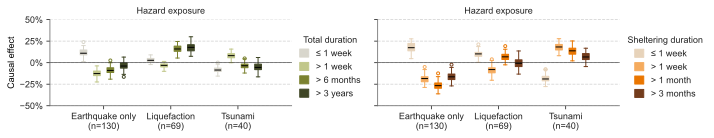

In [6]:
TREATMENTS = [ "hazard_type-earthquake_only", 'hazard_type-liquefaction', 'hazard_type-tsunami']
display_name = 'Hazard exposure'

# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'bin_income', 'occupation-agricultural', 'occupation-business', 'occupation-employment',
'structure-concrete_heavy', 'structure-wood_light', 'structure-wood_heavy', 'housing_quality',
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_hazard.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Household income

<img src="dag/income.png" width="600"> <img src="dag/legend.png" width="200">

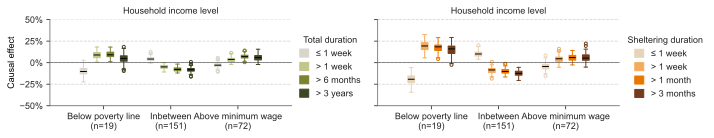

In [7]:
base_var = 'bin_income'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]
display_name = 'Household income level'


# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'occupation-agricultural', 'occupation-business', 'occupation-employment',
'bin_land_tenure', 'bin_dwell_tenure', 'bin_household_size',
] 

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Home and land ownership

<img src="dag/tenure.png" width="600"> <img src="dag/legend.png" width="200">

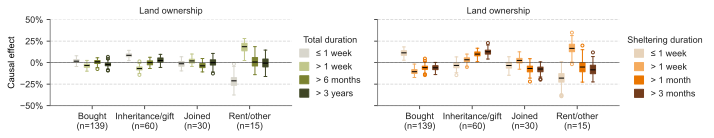

In [8]:
base_var = 'bin_land_tenure'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]
display_name = 'Land ownership'

# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'occupation-agricultural', 'occupation-business', 'occupation-employment',
'bin_income', 'bin_household_size',
'place_identified', 'place_dependent', 'hometown',
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X


results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

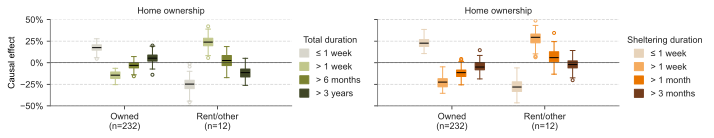

In [9]:
base_var = 'bin_dwell_tenure'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]
display_name = 'Home ownership'

# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'occupation-agricultural', 'occupation-business', 'occupation-employment',
'bin_income', 'bin_household_size',
'place_identified', 'place_dependent', 'hometown',
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X


results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Livelihood type

<img src="dag/livelihood.png" width="600"> <img src="dag/legend.png" width="200">

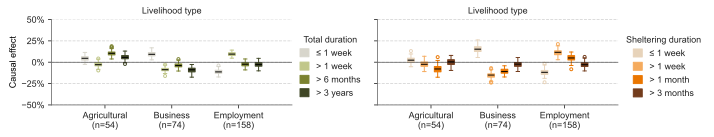

In [10]:
TREATMENTS = ['occupation-agricultural', 'occupation-business', 'occupation-employment']
display_name = 'Livelihood type'

# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'bin_income', 'bin_household_size',
'place_identified', 'place_dependent', 'hometown',
'bin_land_tenure', 'bin_dwell_tenure',
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_livelihood.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Place attachment

<img src="dag/place_attachment.png" width="600"> <img src="dag/legend.png" width="200">

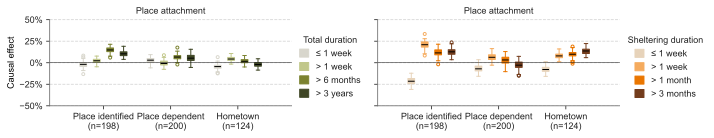

In [11]:
TREATMENTS = ['place_identified', 'place_dependent', 'hometown']
display_name = 'Place attachment'


# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'occupation-agricultural', 'occupation-business', 'occupation-employment',
'bin_income','bin_land_tenure', 'bin_dwell_tenure', 'bin_household_size', 'aspiration_stay',
] 

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_place_attachment.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Household educational attainment

<img src="dag/education.png" width="600"> <img src="dag/legend.png" width="200">

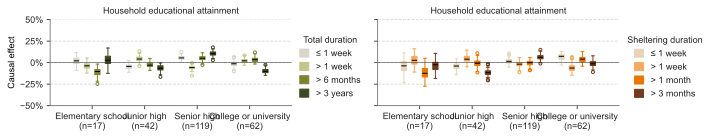

In [12]:
base_var = 'edu_household'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories) if df[base_var + '-' + c].sum() > 15]
display_name = 'Household educational attainment'

# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'occupation-agricultural', 'occupation-business', 'occupation-employment',
'bin_land_tenure', 'bin_dwell_tenure', 'bin_household_size', 'bin_income'
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

### Household size

<img src="dag/household_size.png" width="600"> <img src="dag/legend.png" width="200">

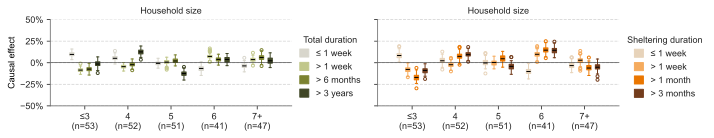

In [13]:
base_var = 'bin_household_size'
TREATMENTS = [base_var + '-' + c for c in list(df[base_var].cat.categories)]
display_name = 'Household size'


# Direct effect
X = ['home_damage', 'comm_damage', 'any_fatality', 'any_injury',
'bin_income', 'occupation-agricultural', 'occupation-business', 'occupation-employment',
]

cols = TREATMENTS + OUTCOME_LEVELS_E + OUTCOME_LEVELS_T + X

results_total = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_T, X)
results_emergency = repeat_dml(data[cols].dropna(), TREATMENTS, OUTCOME_LEVELS_E, X)

output_total[display_name] = results_total
output_shelter[display_name] = results_emergency

fig, axes = plt.subplots(1, 2, figsize=(10, 2), sharex=True, sharey=True)
plot_results(axes[0], results_total, TREATMENTS, OUTCOME_LEVELS_T, data, colors=total_colors, legend_title='Total duration')
plot_results(axes[1], results_emergency, TREATMENTS, OUTCOME_LEVELS_E, data, colors=shelter_colors, legend_title='Sheltering duration')
axes[0].set_title(display_name)
axes[0].set_ylabel('Causal effect')
axes[1].set_title(display_name)
axes[1].yaxis.set_major_formatter('{x:.0%}')
plt.tight_layout()
fig.savefig(os.path.join(img_folder, f"pub_ci_{base_var}.pdf"), dpi=300, facecolor="w", bbox_inches="tight")
plt.show()

## Model evaluation

Choose which model to evaluate. Options:

* 'Home damage level'

* 'Community damage level'

* 'Hazard exposure'

* 'Household casualty'

* 'Household income level'

* 'Land ownership'

* 'Home ownership'

* 'Livelihood type'

* 'Place attachment'

* 'Household educational attainment'

* 'Household size'

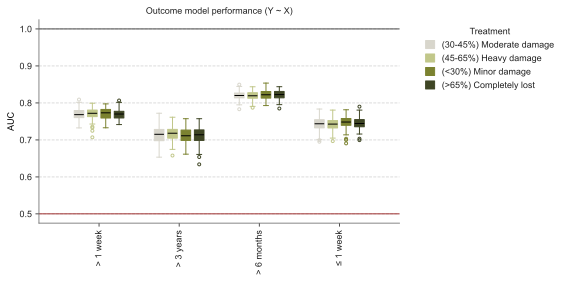

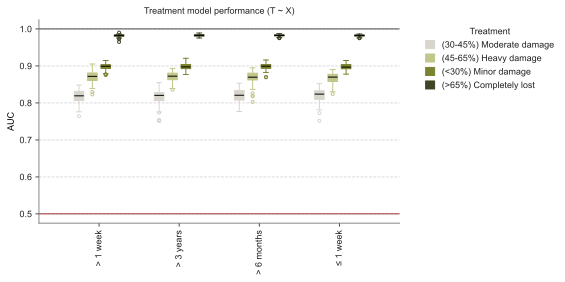

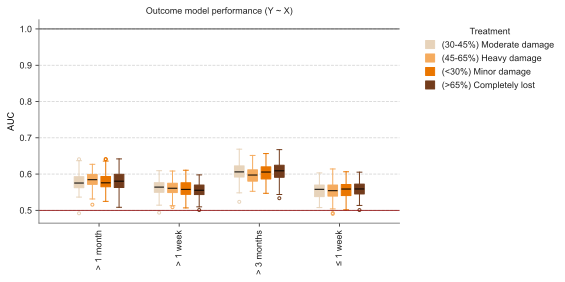

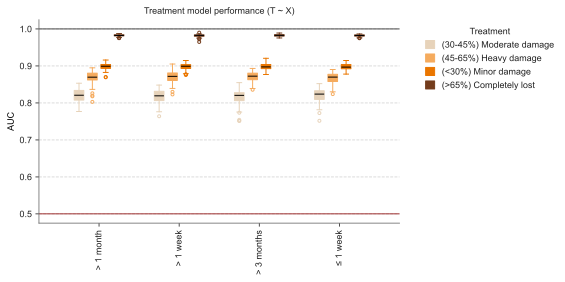

In [14]:
display_name = 'Home damage level'

eval_total = extract_evaluation_table(output_total[display_name])

plot_eval_metrics(eval_total, metric='eval_Y', title='Outcome model performance (Y ~ X)', ylabel='AUC', colors=total_colors)
plot_eval_metrics(eval_total, metric='eval_T', title='Treatment model performance (T ~ X)', ylabel='AUC', colors=total_colors)

eval_emergency = extract_evaluation_table(output_shelter[display_name])

plot_eval_metrics(eval_emergency, metric='eval_Y', title='Outcome model performance (Y ~ X)', ylabel='AUC', colors=shelter_colors)
plot_eval_metrics(eval_emergency, metric='eval_T', title='Treatment model performance (T ~ X)', ylabel='AUC', colors=shelter_colors)

## Extract table

In [15]:
pub_vars = ['Hazard exposure', 'Home damage level', 'Community damage level', 'Home ownership', 'Household income level', 'Livelihood type', 'Place attachment']

pub_tables = [pd.concat([
    output_total[var].pivot(index='treatment', columns='outcome', values='theta_median'),
    output_shelter[var].pivot(index='treatment', columns='outcome', values='theta_median'),
    ], axis=1
    ) for var in pub_vars]

for i in range(len(pub_vars)):
    var = pub_vars[i]
    pub_tables[i].index = var + ': ' + pub_tables[i].index.str.split('-', n=1).str[-1].str.replace('_', ' ').str.capitalize()
    pub_tables[i].columns = [c.split('-').pop() for c in pub_tables[i].columns]

pub_table = pd.concat(pub_tables, axis=0)

pub_table

,> 1 week,> 3 years,> 6 months,≤ 1 week,> 1 month,> 1 week,> 3 months,≤ 1 week
treatment,,,,,,,,
Hazard exposure: Earthquake only,-0.126663,-0.038765,-0.089726,0.109485,-0.266273,-0.184495,-0.164625,0.174090
Hazard exposure: Liquefaction,-0.030834,0.177540,0.159305,0.027816,0.067681,-0.080184,-0.007353,0.101828
Hazard exposure: Tsunami,0.081871,-0.055427,-0.035291,-0.085279,0.137940,0.182283,0.066339,-0.188834
Home damage level: (30-45%) moderate damage,0.036406,-0.060307,-0.003854,-0.029464,-0.031886,-0.112005,-0.034954,0.122923
Home damage level: (45-65%) heavy damage,0.072224,0.043557,0.219116,-0.067039,-0.023072,0.143142,-0.009509,-0.146392
Home damage level: (<30%) minor damage,-0.112121,-0.028731,-0.148032,0.109067,-0.068423,0.022261,-0.067357,-0.004322
Home damage level: (>65%) completely lost,0.047528,0.180886,-0.017482,-0.074099,0.304509,-0.002083,0.332755,-0.031641
Community damage level: (30-45%) moderate damage,0.017236,-0.033271,-0.031973,-0.025085,0.061482,0.110029,-0.013014,-0.121454
Community damage level: (45-65%) heavy damage,0.046775,-0.000764,0.025593,-0.036212,-0.008619,0.006734,0.060954,-0.006746
